# Working with the V1DD functional metrics asset

This notebook shows how to load and query the per-ROI metrics table and
the three array archives that ship alongside it. See
[outputs.md](../outputs.md) for the full column reference.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# In Code Ocean the asset mounts at /data; locally, point to the results directory.
ASSET = Path("../../results/409828_V1DD_functional_metrics_2026-09-14_22-59-50")
assert ASSET.exists(), f"Asset not found at {ASSET}. Adjust the path for your environment."


## The per-ROI table

`stimulus_metrics.parquet` has one row per ROI (39,407 rows, 110 columns).
Nine identity columns, then metric blocks grouped by analysis family.


In [2]:
df = pd.read_parquet(ASSET / "stimulus_metrics.parquet")
print(f"{len(df):,} ROIs × {len(df.columns)} columns")
print(f"Sessions: {df.groupby(['column', 'volume']).ngroups}")
print(f"Planes: {df.groupby(['column', 'volume', 'plane']).ngroups}")
df[["roi_key", "column", "volume", "plane", "roi", "depth_um",
    "pika_roi_confidence", "snr", "dgw_osi", "dgw_dsi"]].head(10)


39,407 ROIs × 110 columns
Sessions: 25
Planes: 150


,roi_key,column,volume,plane,roi,depth_um,pika_roi_confidence,snr,dgw_osi,dgw_dsi
0,M409828_2_1_0_0,2,1,0,0,50.0,0.916531,2.066006,0.164965,0.215925
1,M409828_2_1_0_1,2,1,0,1,50.0,0.916861,4.994294,0.032355,-0.252092
2,M409828_2_1_0_2,2,1,0,2,50.0,0.913705,1.512380,0.145612,0.555328
3,M409828_2_1_0_4,2,1,0,4,50.0,0.915848,1.650628,0.361582,0.203504
4,M409828_2_1_0_5,2,1,0,5,50.0,0.912224,1.182687,-0.183021,-0.286439
5,M409828_2_1_0_7,2,1,0,7,50.0,0.912520,1.292208,0.175373,0.152540
6,M409828_2_1_0_9,2,1,0,9,50.0,0.916683,1.335652,-0.144510,-0.027944
7,M409828_2_1_0_65,2,1,0,65,50.0,0.912281,1.573800,-0.107729,-0.070188
8,M409828_2_1_0_149,2,1,0,149,50.0,0.522310,1.475334,0.086028,0.006679
9,M409828_2_1_1_0,2,1,1,0,66.0,0.917007,6.757952,-0.085586,0.017606


### Filtering by session

Join on `roi_key` or on `(column, volume, plane, roi)`.
`volume` is a string (values include hex digits in other datasets).


In [3]:
session = df[(df.column == 1) & (df.volume == "3")]
print(f"Column 1, Volume 3: {len(session):,} ROIs across {session.plane.nunique()} planes")
print(f"Depth range: {session.depth_um.min():.0f}–{session.depth_um.max():.0f} µm")
print(f"Median SNR: {session.snr.median():.1f}")
print(f"Median confidence: {session.pika_roi_confidence.median():.2f}")


Column 1, Volume 3: 2,708 ROIs across 6 planes
Depth range: 242–322 µm
Median SNR: 1.4
Median confidence: 0.92


## Tuning curves

`tuning_curves.npz` holds per-trial grating responses. The main arrays are
`dgw_trials` and `dgf_trials`, each (n_rois, 12 directions, 2 spatial frequencies, 8 trials).
Rows align with the parquet via `roi_key`.


In [4]:
tc = np.load(ASSET / "tuning_curves.npz", allow_pickle=True)
print("Arrays:", list(tc.files))
print(f"dgw_trials: {tc['dgw_trials'].shape}  (ROIs × dirs × SFs × trials)")
print(f"directions: {tc['directions']}")
print(f"spatial_frequencies: {tc['spatial_frequencies']}")


Arrays: ['roi_key', 'plane_key', 'directions', 'spatial_frequencies', 'trace_type', 'dgw_trials', 'dgw_blank', 'dgw_n_blank', 'dgw_params', 'dgw_running', 'dgf_trials', 'dgf_blank', 'dgf_n_blank', 'dgf_params', 'dgf_running']


dgw_trials: (39407, 12, 2, 8)  (ROIs × dirs × SFs × trials)
directions: [  0.  30.  60.  90. 120. 150. 180. 210. 240. 270. 300. 330.]
spatial_frequencies: [0.04 0.08]


Example ROI: M409828_2_1_1_8  (OSI=0.95, pref_dir=300°)


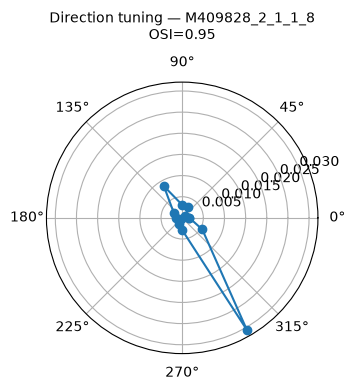

In [5]:
# Pick a well-tuned ROI: high OSI, high confidence
candidates = df[(df.dgw_osi > 0.8) & (df.pika_roi_confidence > 0.9) & (df.snr > 5)]
example = candidates.iloc[0]
idx = df.index.get_loc(example.name)
print(f"Example ROI: {example.roi_key}  (OSI={example.dgw_osi:.2f}, pref_dir={example.dgw_preferred_dir:.0f}°)")

# Trial-mean tuning curve at the preferred spatial frequency.
# dgw_preferred_sf is the SF value (0.04/0.08), not an index — map it to the SF axis.
sf_idx = int(np.argmin(np.abs(tc["spatial_frequencies"] - example.dgw_preferred_sf)))
trials = tc["dgw_trials"][idx, :, sf_idx, :]  # (12 dirs, 8 trials)
mean_resp = np.nanmean(trials, axis=1)
dirs_rad = np.deg2rad(tc["directions"])

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))
ax.plot(np.append(dirs_rad, dirs_rad[0]), np.append(mean_resp, mean_resp[0]), "o-", lw=1.5)
ax.set_title(f"Direction tuning — {example.roi_key}\nOSI={example.dgw_osi:.2f}", fontsize=10, pad=12)
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
plt.tight_layout()
plt.show()

## Receptive field maps

`receptive_field_maps.npz` holds the **greedy** receptive-field archive. `rf_sta`
(n_rois, 2, 8 altitudes, 14 azimuths) is the stimulus-triggered average of L0 events
(dimension 1: index 0 = ON, 1 = OFF); `strict_mask` (same shape, bool) marks the
significant pixels after the Holm-Šidák correction at `alpha_strict`; `rf_ge` holds the
per-pixel bootstrap shuffle-counts, from which any α's mask is reproducible. The
`has_rf_on` / `has_rf_off` columns and the RF centres in the table come from `strict_mask`.
(Under `rf_method="fraction"` the archive instead holds `rf_maps`, the pre-threshold
fraction maps.)

The example below picks an ROI with an ON field but **no** OFF field, and draws both
subfields on a **shared color scale** (both are raw STA in event units). The ON STA
stands out at its significant pixel (cyan); the OFF panel is uniformly dim — i.e.
uninterpretable noise, which is the honest reading when `strict_mask` finds nothing there.

Arrays: ['method', 'rf_sta', 'rf_ge', 'strict_mask', 'n_boot', 'alpha_strict', 'alpha_sens', 'roi_key', 'altitudes', 'azimuths', 'seed']


rf_sta: (39407, 2, 8, 14)   strict_mask: (39407, 2, 8, 14)
alpha_strict=0.01, alpha_sens=0.05, n_boot=5000


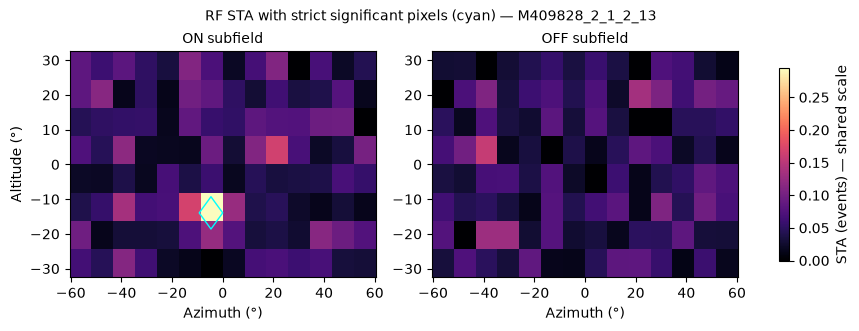

In [6]:
rf = np.load(ASSET / "receptive_field_maps.npz", allow_pickle=True)
print("Arrays:", list(rf.files))
print(f"rf_sta: {rf['rf_sta'].shape}   strict_mask: {rf['strict_mask'].shape}")
print(f"alpha_strict={float(rf['alpha_strict'])}, alpha_sens={float(rf['alpha_sens'])}, n_boot={int(rf['n_boot'])}")

# An ON-only ROI: a clear ON field, no significant OFF field (the uninterpretable panel)
on_only = df[df.has_rf_on & ~df.has_rf_off]
ex_rf = on_only.sort_values("snr", ascending=False).iloc[0]
rf_idx = df.index.get_loc(ex_rf.name)
alt, azi = rf["altitudes"], rf["azimuths"]

# Shared color scale across both subfields (raw STA, same event units) so the OFF panel
# reads as the noise it is rather than being auto-stretched to look structured.
vmax = float(rf["rf_sta"][rf_idx].max())

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), layout="constrained")
for i, (ax, label) in enumerate(zip(axes, ["ON", "OFF"])):
    sta = rf["rf_sta"][rf_idx, i]
    mask = rf["strict_mask"][rf_idx, i]
    im = ax.imshow(sta, aspect="auto", cmap="magma", origin="lower", vmin=0, vmax=vmax,
                   extent=[azi[0], azi[-1], alt[0], alt[-1]])
    if mask.any():
        ax.contour(azi, alt, mask.astype(float), levels=[0.5], colors="cyan", linewidths=1.0)
    ax.set_title(f"{label} subfield", fontsize=10)
    ax.set_xlabel("Azimuth (°)")
axes[0].set_ylabel("Altitude (°)")
fig.colorbar(im, ax=axes, shrink=0.85, label="STA (events) — shared scale")
fig.suptitle(f"RF STA with strict significant pixels (cyan) — {ex_rf.roi_key}", fontsize=10)
plt.show()

## Condition means (natural images)

`condition_means.npz` holds trial-averaged responses: `ni_mean` (n_rois, 118 images)
and `ni12_mean` (n_rois, 12 images). Every published natural-image column is a
reduction of these matrices.


ni_mean: (39407, 118)  (ROIs × 118 images)
ni12_mean: (39407, 12)  (ROIs × 12 images)


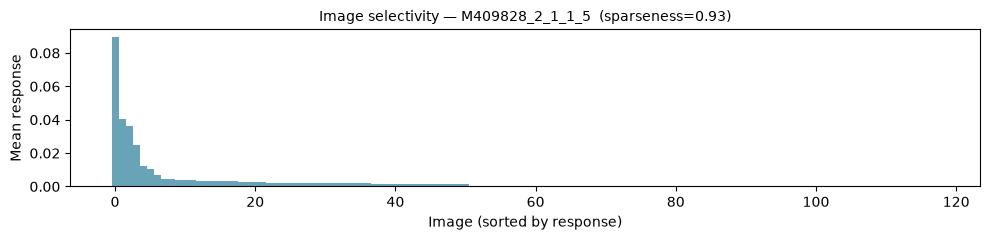

In [7]:
cm = np.load(ASSET / "condition_means.npz", allow_pickle=True)
print(f"ni_mean: {cm['ni_mean'].shape}  (ROIs × 118 images)")
print(f"ni12_mean: {cm['ni12_mean'].shape}  (ROIs × 12 images)")

# Show mean responses for a selective ROI
sparse_rois = df[df.ni_lifetime_sparseness > 0.9]
ex_ni = sparse_rois.iloc[0]
ni_idx = df.index.get_loc(ex_ni.name)

fig, ax = plt.subplots(figsize=(10, 2.5))
responses = cm["ni_mean"][ni_idx]
order = np.argsort(responses)[::-1]
ax.bar(range(118), responses[order], width=1, color="#2a7d9a", alpha=0.7)
ax.set_xlabel("Image (sorted by response)")
ax.set_ylabel("Mean response")
ax.set_title(f"Image selectivity — {ex_ni.roi_key}  (sparseness={ex_ni.ni_lifetime_sparseness:.2f})", fontsize=10)
plt.tight_layout()
plt.show()


## Metrics by family

Every scalar metric is a column in `stimulus_metrics.parquet`, prefixed by the family
that produced it (families whose names already name the stimulus keep an empty prefix).
The cells below pull each family's block and run one representative query. See
[outputs.md](../outputs.md) for the full column reference.

In [8]:
# ROI quality & activity (roi_summary): recording quality, spontaneous rate,
# running modulation, and the dF/F running correlation. No prefix.
q = ["snr", "signal_power", "noise_power", "spont_rate", "spont_rate_run",
     "spont_rate_stat", "run_frac", "run_mod_dgw", "run_mod_dgf", "run_mod_spont",
     "run_corr_dff"]
print("running-modulated cells (|run_mod_dgw| > 0.3):",
      int((df.run_mod_dgw.abs() > 0.3).sum()))
df[["roi_key"] + q].describe().T[["mean", "50%", "min", "max"]]

running-modulated cells (|run_mod_dgw| > 0.3): 8426


,mean,50%,min,max
snr,1.717271e+00,1.392489e+00,0.841688,3.045662e+01
signal_power,3.054272e+06,1.882643e+06,206273.728923,4.449695e+08
noise_power,1.730564e+06,1.275460e+06,123535.469723,1.052105e+08
spont_rate,6.940196e-04,5.907593e-04,0.000159,2.676029e-02
spont_rate_run,6.042567e-04,3.997775e-04,0.000000,1.446053e-01
spont_rate_stat,7.310689e-04,6.208863e-04,0.000000,4.068974e-02
run_frac,2.938001e-01,3.059941e-01,0.040236,6.940155e-01
run_mod_dgw,9.618570e-02,1.156854e-01,-1.000000,9.502596e-01
run_mod_dgf,-4.116436e-02,-3.471972e-02,-1.000000,1.000000e+00
run_mod_spont,-2.884813e-01,-1.806875e-01,-1.000000,1.000000e+00


In [9]:
# Drifting gratings, full-field (dgf_) and windowed (dgw_): tuning and selectivity.
# osi/dsi are split-half CROSS-VALIDATED (gosi, preferred_dir, pref_dir_mean stay naive).
dgw = [c for c in df.columns if c.startswith("dgw_")]
print("dgw_ columns:", dgw)
# responsive, orientation-selective cells
sel = df[(df.dgw_is_responsive == 1) & (df.dgw_osi > 0.5)]
print(f"\nresponsive & OSI>0.5: {len(sel):,} ROIs")
df.loc[sel.index, ["roi_key", "dgw_osi", "dgw_dsi", "dgw_gosi",
                   "dgw_preferred_dir", "dgw_preferred_sf"]].head()

dgw_ columns: ['dgw_dsi', 'dgw_frac_responsive_trials', 'dgw_gosi', 'dgw_is_responsive', 'dgw_lifetime_sparseness', 'dgw_osi', 'dgw_preferred_dir', 'dgw_preferred_sf', 'dgw_pref_dir_mean', 'dgw_center_azimuth', 'dgw_center_elevation', 'dgw_center_inferred', 'dgw_rf_distance_on', 'dgw_rf_distance_off', 'dgw_rf_overlap_on', 'dgw_rf_overlap_off']

responsive & OSI>0.5: 4,904 ROIs


,roi_key,dgw_osi,dgw_dsi,dgw_gosi,dgw_preferred_dir,dgw_preferred_sf
11,M409828_2_1_1_2,0.681105,0.695493,0.534129,60.0,0.08
12,M409828_2_1_1_3,0.882429,0.681480,0.683741,90.0,0.08
14,M409828_2_1_1_5,0.882532,0.372663,0.661341,0.0,0.08
17,M409828_2_1_1_8,0.952396,0.526740,0.664764,300.0,0.08
18,M409828_2_1_1_9,0.940954,-0.095454,0.637666,60.0,0.04


In [10]:
# Surround suppression (ssi_*) plus the aperture geometry (dgw_center_*, dgw_rf_*)
# and the plane population RF (pop_rf_*). All live in the same block, unprefixed.
ss = [c for c in df.columns if c.startswith("ssi")
      or c.startswith("dgw_center") or c.startswith("dgw_rf") or c.startswith("pop_rf")]
print(ss)
df[["roi_key", "ssi", "ssi_avg_at_pref_sf", "dgw_rf_overlap_on",
    "pop_rf_azimuth", "pop_rf_altitude"]].dropna(subset=["ssi"]).head()

['ssi', 'ssi_avg', 'ssi_avg_at_pref_sf', 'ssi_running', 'ssi_running_avg_at_pref_sf', 'ssi_stationary', 'ssi_stationary_avg_at_pref_sf', 'ssi_tuning_fit', 'dgw_center_azimuth', 'dgw_center_elevation', 'dgw_center_inferred', 'dgw_rf_distance_on', 'dgw_rf_distance_off', 'dgw_rf_overlap_on', 'dgw_rf_overlap_off', 'pop_rf_azimuth', 'pop_rf_altitude', 'pop_rf_dis_azimuth', 'pop_rf_dis_altitude']


,roi_key,ssi,ssi_avg_at_pref_sf,dgw_rf_overlap_on,pop_rf_azimuth,pop_rf_altitude
0,M409828_2_1_0_0,0.169997,0.138997,0.0,-4.65,-1.55
1,M409828_2_1_0_1,0.315031,0.069426,NaN,-4.65,-1.55
2,M409828_2_1_0_2,0.125412,0.027518,NaN,-4.65,-1.55
3,M409828_2_1_0_4,-0.409028,-0.051058,NaN,-4.65,-1.55
4,M409828_2_1_0_5,0.569689,0.013309,NaN,-4.65,-1.55


In [11]:
# Natural scenes: 118-image (ni_), 12-image repeat (ni12_), movie (nm_).
# Same 8-column layout each; pref_img is a catalog image index (ni/ni12) or a
# frame index (nm). condition_means.npz above holds the per-image response vectors.
for pfx in ("ni_", "ni12_", "nm_"):
    cols = [c for c in df.columns if c.startswith(pfx)]
    print(f"{pfx:6s} {[c[len(pfx):] for c in cols]}")
df[["roi_key", "ni_pref_img", "ni_pref_response", "ni_reliability", "ni_z_score",
    "nm_pref_img"]].head()

ni_    ['frac_responsive_trials', 'lifetime_sparseness', 'pref_img', 'pref_response', 'z_score', 'reliability', 'reliability_events', 'n_trials_at_pref']
ni12_  ['frac_responsive_trials', 'lifetime_sparseness', 'pref_img', 'pref_response', 'z_score', 'reliability', 'reliability_events', 'n_trials_at_pref']
nm_    ['frac_responsive_trials', 'lifetime_sparseness', 'pref_img', 'pref_response', 'z_score', 'reliability', 'reliability_events', 'n_trials_at_pref']


,roi_key,ni_pref_img,ni_pref_response,ni_reliability,ni_z_score,nm_pref_img
0,M409828_2_1_0_0,95,0.008813,0.043083,5.444753,128
1,M409828_2_1_0_1,32,0.232657,0.309769,157.865493,2700
2,M409828_2_1_0_2,1,0.009260,0.082035,4.199421,1383
3,M409828_2_1_0_4,20,0.008806,0.055614,6.593404,1089
4,M409828_2_1_0_5,106,0.018676,0.252832,8.474232,12


In [12]:
# Receptive-field metrics (rf_metrics block, unprefixed): detection, centres, and
# area for the strict default, with the sensitive variant under the _a05 suffix.
strict = ["has_rf_on", "has_rf_off", "has_rf_on_or_off", "azimuth_rf_on",
          "altitude_rf_on", "azimuth_rf_off", "altitude_rf_off", "rf_on_area", "rf_off_area"]
print("strict :", strict)
print("sensitive:", [c + "_a05" for c in strict])
print(f"\nON detection  strict {df.has_rf_on.mean():.1%}   sensitive {df.has_rf_on_a05.mean():.1%}")
df.loc[df.has_rf_on, ["roi_key", "azimuth_rf_on", "altitude_rf_on", "rf_on_area"]].head()

strict : ['has_rf_on', 'has_rf_off', 'has_rf_on_or_off', 'azimuth_rf_on', 'altitude_rf_on', 'azimuth_rf_off', 'altitude_rf_off', 'rf_on_area', 'rf_off_area']
sensitive: ['has_rf_on_a05', 'has_rf_off_a05', 'has_rf_on_or_off_a05', 'azimuth_rf_on_a05', 'altitude_rf_on_a05', 'azimuth_rf_off_a05', 'altitude_rf_off_a05', 'rf_on_area_a05', 'rf_off_area_a05']

ON detection  strict 8.5%   sensitive 11.7%


,roi_key,azimuth_rf_on,altitude_rf_on,rf_on_area
0,M409828_2_1_0_0,13.95,13.95,86.49
6,M409828_2_1_0_9,-13.95,-13.95,86.49
7,M409828_2_1_0_65,-13.95,-4.65,86.49
14,M409828_2_1_1_5,-4.65,-4.65,86.49
20,M409828_2_1_1_11,-60.45,23.25,86.49


In [13]:
# ROI position (roi_position block, unprefixed): pixel centroid and size, plus
# micrometre coordinates in two anatomical frames (published grid vs retinotopic fit).
pos = [c for c in df.columns if c.startswith("roi_")
       and c not in ("roi_key", "roi_unique_id", "roi")]
print(pos)
df[["roi_key", "roi_area_px", "roi_radius_px",
    "roi_x_um_published", "roi_y_um_published",
    "roi_x_um_retinotopic", "roi_y_um_retinotopic"]].head()

['roi_x_px', 'roi_y_px', 'roi_area_px', 'roi_radius_px', 'roi_x_um', 'roi_y_um', 'roi_x_um_published', 'roi_y_um_published', 'roi_x_um_retinotopic', 'roi_y_um_retinotopic']


,roi_key,roi_area_px,roi_radius_px,roi_x_um_published,roi_y_um_published,roi_x_um_retinotopic,roi_y_um_retinotopic
0,M409828_2_1_0_0,186.0,7.694520,-111.223118,409.198589,-99.284925,251.380666
1,M409828_2_1_0_1,193.0,7.837972,-38.884391,427.096826,-26.946198,269.278904
2,M409828_2_1_0_2,222.0,8.406235,-8.255912,284.403153,3.682281,126.585231
3,M409828_2_1_0_4,171.0,7.377736,-74.410636,466.620980,-62.472442,308.803057
4,M409828_2_1_0_5,196.0,7.898654,-94.411671,485.275829,-82.473477,327.457907


## Provenance

`provenance.json` records the config, sessions processed, runtime breakdown,
and what differs from the reference configuration.


In [14]:
import json

with open(ASSET / "provenance.json") as f:
    prov = json.load(f)

print(f"Git SHA: {prov['git_sha']}")
print(f"Complete asset: {prov['complete_asset']}")
print(f"Wall time: {prov['wall_seconds'] / 3600:.2f} h")
print(f"Sessions: {len(prov['sessions'])}")
print(f"Failed: {prov['failed_sessions']}")
print(f"\nStage seconds (top 5):")
for stage, sec in sorted(prov["stage_seconds"].items(), key=lambda x: -x[1])[:5]:
    print(f"  {stage}: {sec:.0f}s ({sec/prov['wall_seconds']*100:.1f}%)")


Git SHA: 1d891836be57d84274f6397e798758439f92f552
Complete asset: True
Wall time: 7.35 h
Sessions: 25
Failed: []

Stage seconds (top 5):
  receptive_fields: 7138s (27.0%)
  drifting_gratings_windowed: 6927s (26.2%)
  drifting_gratings_full: 6584s (24.9%)
  load_traces: 1360s (5.1%)
  natural_movie: 354s (1.3%)
